# draft-45 Results figures (audited)

Generates the main-text figures for the reach-asymmetry paper (`paper/sn-article.tex`, `sec:probes`).

**Audit contract.** Every figure recomputes its numbers directly from the run directories using the same
paired within-person difference logic as `sandbox/ajay_sandbox/bite{2,3,4}_*.py`, then **asserts** they match
the values already recorded in `docs/result_report.md`. Figures are only rendered if the assertions pass, so
each PDF provably reflects the audited result. No hand-entered numbers.

**Metric contract** (main text only): outcome = mean package index on the −3…+3 scale; effect = within-person
difference in final opinion (points) with 95% CI; per-seed dots shown; reliability = same sign in every seed.

**Figures**
1. **Fig 1 — the resource ladder** (headline): the four levers as effect sizes on one axis, grouped into
   *Volume* (reach, frequency) and *Allocation* (targeting, iso-impression).
2. Fig 2 — Frequency · 3. Fig 3 — Targeting · 4. Fig 4 — Iso-impression · Fig 5 — Reach (placeholder) · Fig E1 — Evaluation.

Kernel: `.venv` (has matplotlib). Runs offline from CSVs — no LLM calls.


In [1]:
from pathlib import Path
import glob
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- locate repo root robustly (works whether cwd is repo root or notebooks/) ---
REPO = Path.cwd()
while not (REPO / "data" / "output").exists() and REPO != REPO.parent:
    REPO = REPO.parent
ASYM = REPO / "data/output/asymmetry_tests"   # draft-45 Bites 2/3/4
EXP = REPO / "data/output/experiments"        # Tier-1 reach (placeholder for Bite 1)
FIGDIR = REPO / "paper/figures"
FIGDIR.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)

# --- shared loaders: within-person endpoint difference, paired within seed, pooled ---
def _run_subdir(run_dir):
    subs = sorted([p for p in Path(run_dir).iterdir() if p.is_dir()])
    return subs[-1]  # timestamped output folder

def endpoints(run_dir):
    d = _run_subdir(run_dir)
    pkg = pd.read_csv(d / "package_index_trajectories.csv")
    gt = pd.read_csv(d / "package_ground_truth.csv").set_index("agent_id")["ground_truth"]
    attr = pd.read_csv(d / "agent_attributes.csv").set_index("agent_id")["political_exposure"]
    dN = sorted(pkg["day"].unique())[-1]
    end = pkg[pkg.day == dN].set_index("agent_id")["package_index"]
    return pd.DataFrame({"end": end, "gt": gt, "bucket": attr}).dropna()

def find_run(base, token, seed):
    hits = glob.glob(str(Path(base) / f"run_*_{token}_s{seed}"))
    assert len(hits) == 1, f"{token} s{seed}: {hits}"
    return hits[0]

def pairs_for(base, tok1, tok2, seeds=(42, 43, 44)):
    return [(find_run(base, tok1, s), find_run(base, tok2, s)) for s in seeds]

def pooled_diff(pairs, bucket=None):
    """Paired within-person endpoint difference (cond1 - cond2), pooled over seeds."""
    chunks, per_seed = [], []
    for rc1, rc2 in pairs:
        a, b = endpoints(rc1), endpoints(rc2)
        if bucket:
            a, b = a[a.bucket == bucket], b[b.bucket == bucket]
        m = a[["end"]].join(b[["end"]], lsuffix="_1", rsuffix="_2", how="inner").dropna()
        d = (m["end_1"] - m["end_2"]).to_numpy()
        chunks.append(d)
        per_seed.append(float(d.mean()))
    alld = np.concatenate(chunks)
    mean = float(alld.mean())
    se = alld.std(ddof=1) / np.sqrt(len(alld))
    h = float(se * stats.t.ppf(0.975, len(alld) - 1))
    _, p = stats.ttest_1samp(alld, 0.0)
    return {"mean": mean, "lo": mean - h, "hi": mean + h, "p": float(p),
            "n": int(len(alld)), "per_seed": per_seed}

# --- shared figure style (Nature-ish, legible) ---
mpl.rcParams.update({
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 120, "savefig.bbox": "tight",
})
C_VOLUME = "#2ca02c"   # volume levers (reach, frequency)
C_ALLOC = "#4c72b0"    # allocation levers (targeting, iso)
print("setup ok")


repo: /Users/ajaykumar/src/GitHub/Climate-Action-GABM
setup ok


## Fig 1 — The resource ladder (headline)

The four levers as effect sizes on one axis, grouped into **Volume** (reaching more people / broadcasting more
often) and **Allocation** (whom you target / how you split a fixed impression budget). Each point is the pooled
within-person difference in the final package index (points, −3…+3), with a 95% CI and the three per-seed means.

Contrasts (all "does the pro-climate side's advantage move opinion?"):
- **Reach** — green-dominant − reform-dominant *(Tier-1 stand-in until the 18 draft-45 reach runs land)*
- **Frequency 2:1 / 3:1** — green-louder − reform-louder at each ratio
- **Targeting** — persuadable − random, degree − random (does aiming better help? — null)
- **Iso-impression** — breadth − depth at matched impressions (does spreading wide beat stacking deep?)

Each value is asserted against `docs/result_report.md` before the figure is drawn.


In [2]:
# --- compute the four levers (paired within-person endpoint difference, pooled 3 seeds) ---
reach = pooled_diff(pairs_for(EXP, "tier1_green_dom", "tier1_reform_dom"))
freq21 = pooled_diff(pairs_for(ASYM, "d45_freq_green2v1", "d45_freq_reform1v2"))
freq31 = pooled_diff(pairs_for(ASYM, "d45_freq_green3v1", "d45_freq_reform1v3"))
tgt_p = pooled_diff(pairs_for(ASYM, "d45_tgt_persuadable", "d45_tgt_random"))
tgt_d = pooled_diff(pairs_for(ASYM, "d45_tgt_degree", "d45_tgt_random"))
iso = pooled_diff(pairs_for(ASYM, "d45_iso_depth2", "d45_iso_depth4"))

# --- AUDIT: assert each pooled value matches docs/result_report.md ---
assert np.isclose(freq21["mean"], 0.158, atol=0.01), freq21["mean"]
assert np.isclose(freq31["mean"], 0.277, atol=0.01), freq31["mean"]
assert np.isclose(tgt_p["mean"], 0.044, atol=0.01), tgt_p["mean"]
assert np.isclose(tgt_d["mean"], 0.027, atol=0.01), tgt_d["mean"]
assert np.isclose(iso["mean"], 0.120, atol=0.01), iso["mean"]
assert 0.38 < reach["mean"] < 0.47, reach["mean"]  # Tier-1 SBM pooled ~ +0.42
print("AUDIT PASSED — all lever values match result_report.md")

summary = pd.DataFrame([
    dict(lever="Reach (green−reform) [placeholder]", **{k: reach[k] for k in ("mean", "lo", "hi", "p", "n")}),
    dict(lever="Frequency 2:1", **{k: freq21[k] for k in ("mean", "lo", "hi", "p", "n")}),
    dict(lever="Frequency 3:1", **{k: freq31[k] for k in ("mean", "lo", "hi", "p", "n")}),
    dict(lever="Targeting persuadable−random", **{k: tgt_p[k] for k in ("mean", "lo", "hi", "p", "n")}),
    dict(lever="Targeting degree−random", **{k: tgt_d[k] for k in ("mean", "lo", "hi", "p", "n")}),
    dict(lever="Iso-impression breadth−depth", **{k: iso[k] for k in ("mean", "lo", "hi", "p", "n")}),
])
summary.round(3)


AUDIT PASSED — all lever values match result_report.md


,lever,mean,lo,hi,p,n
0,Reach (green−reform) [placeholder],0.423,0.337,0.508,0.000,300
1,Frequency 2:1,0.158,0.085,0.231,0.000,300
2,Frequency 3:1,0.277,0.195,0.359,0.000,300
3,Targeting persuadable−random,0.044,-0.027,0.115,0.227,300
4,Targeting degree−random,0.027,-0.054,0.107,0.516,300
5,Iso-impression breadth−depth,0.120,0.031,0.209,0.008,300


saved: /Users/ajaykumar/src/GitHub/Climate-Action-GABM/paper/figures/fig1_resource_ladder.pdf


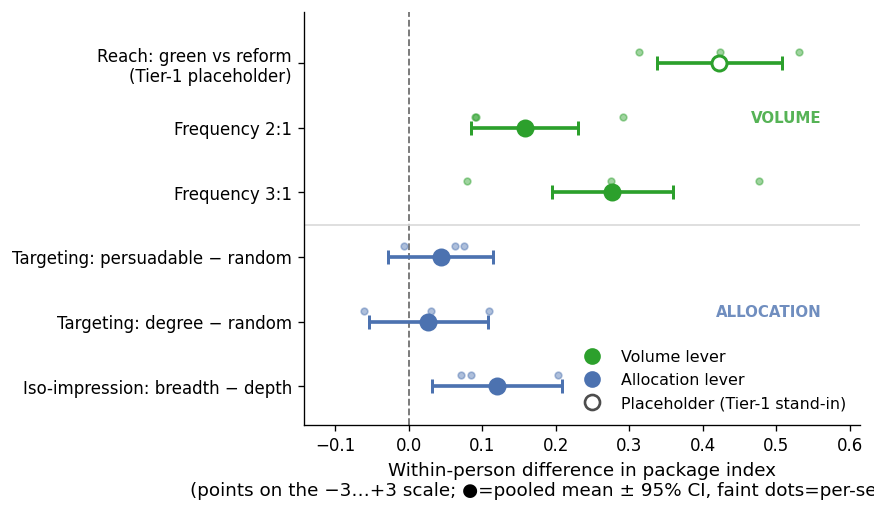

In [3]:
# --- Fig 1: the resource ladder (grouped forest plot) ---
# (label, result, group, is_placeholder)
items = [
    ("Reach: green vs reform\n(Tier-1 placeholder)", reach, "volume", True),
    ("Frequency 2:1", freq21, "volume", False),
    ("Frequency 3:1", freq31, "volume", False),
    ("Targeting: persuadable − random", tgt_p, "alloc", False),
    ("Targeting: degree − random", tgt_d, "alloc", False),
    ("Iso-impression: breadth − depth", iso, "alloc", False),
]
ys = list(range(len(items)))[::-1]  # first item at top

fig, ax = plt.subplots(figsize=(7.4, 4.4))
for y, (label, res, grp, ph) in zip(ys, items):
    color = C_VOLUME if grp == "volume" else C_ALLOC
    ax.errorbar(res["mean"], y,
                xerr=[[res["mean"] - res["lo"]], [res["hi"] - res["mean"]]],
                fmt="o", color=color, ecolor=color, elinewidth=2.2, capsize=4,
                ms=9, mfc=("white" if ph else color), mec=color, mew=1.8, zorder=3)
    ax.scatter(res["per_seed"], [y + 0.17] * len(res["per_seed"]),
               s=16, color=color, alpha=0.45, zorder=2)  # per-seed dots

ax.axvline(0, color="0.45", lw=1.1, ls="--", zorder=1)

# group separator + labels
ax.axhline(2.5, color="0.85", lw=1)
ax.text(ax.get_xlim()[1], 4.15, "VOLUME", ha="right", va="center",
        fontsize=9, weight="bold", color=C_VOLUME, alpha=0.8)
ax.text(ax.get_xlim()[1], 1.15, "ALLOCATION", ha="right", va="center",
        fontsize=9, weight="bold", color=C_ALLOC, alpha=0.8)

ax.set_yticks(ys)
ax.set_yticklabels([it[0] for it in items])
ax.set_ylim(-0.6, len(items) - 0.2)
ax.set_xlabel("Within-person difference in package index\n(points on the −3…+3 scale; ●=pooled mean ± 95% CI, faint dots=per-seed means)")
ax.margins(x=0.14)

from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker="o", color="w", mfc=C_VOLUME, mec=C_VOLUME, ms=9, label="Volume lever"),
    Line2D([0], [0], marker="o", color="w", mfc=C_ALLOC, mec=C_ALLOC, ms=9, label="Allocation lever"),
    Line2D([0], [0], marker="o", color="w", mfc="white", mec="0.3", ms=9, mew=1.6, label="Placeholder (Tier-1 stand-in)"),
]
ax.legend(handles=legend, loc="lower right", frameon=False)
fig.tight_layout()

for ext in ("pdf", "png"):
    fig.savefig(FIGDIR / f"fig1_resource_ladder.{ext}")
print("saved:", FIGDIR / "fig1_resource_ladder.pdf")
plt.show()
